# PhillyStat360 — 04e: Operational thresholds & capacity flags

Translates `ensemble_prob` into a deployable flag list. Instead of a single citywide threshold, this notebook applies a **per-ward inspection budget** — the city can absorb only so many leads per ward per cycle, and the model should respect that. We then compare the precision of three operational rules at the same total capacity:

1. Model-only (top-N by `ensemble_prob` per ward)
2. VPI-only (everything the City already flags)
3. Union (every parcel either model flags)

**Outputs**
- `data_py/operational_flags_by_ward.csv` — parcel-level flags under model-only rule
- `data_py/operational_precision_at_capacity.csv` — headline comparison table
- `graphs/python/operational_precision_at_capacity.png`


## 0. Setup

In [ ]:
# Mount Drive in Colab; pass through locally.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not in Colab — using local paths.')


Mounted at /content/drive


In [ ]:
from pathlib import Path

if IN_COLAB:
    ROOT = Path('/content/drive/MyDrive/PhillyStat_R/PhillyStat360')
else:
    ROOT = Path('G:/My Drive/PhillyStat_R/PhillyStat360')

RAW_PATH   = ROOT / 'rawdata'
DATA_PATH  = ROOT / 'data'
PY_PATH    = ROOT / 'data_py'
OUT_PATH   = ROOT / 'data_py'
GRAPH_PATH = ROOT / 'graphs' / 'python'
OUT_PATH.mkdir(parents=True, exist_ok=True)
GRAPH_PATH.mkdir(parents=True, exist_ok=True)
print('ROOT =', ROOT)


ROOT = /content/drive/MyDrive/PhillyStat_R/PhillyStat360


In [ ]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='talk')
SEED = 42


## 1. Load merged parcel-level frame

Reuses `vs_city_vpi_parcel.csv` from 04c (has parcel_number, ovs, ensemble_prob, vpi_flag, ward, ZIP, category).

In [ ]:
src = OUT_PATH / 'vs_city_vpi_parcel.csv'
if not src.exists():
    raise FileNotFoundError(f'{src} not found — run 04c_vs_city_vpi.ipynb first.')
df = pd.read_csv(src, low_memory=False)
df['parcel_number'] = df['parcel_number'].astype(str).str.strip()

# Pull in geographic_ward from predictions_04b if not already present
if 'geographic_ward' not in df.columns:
    p04b = pd.read_csv(PY_PATH / 'predictions_04b.csv',
                       usecols=['parcel_number', 'geographic_ward'], low_memory=False)
    p04b['parcel_number'] = p04b['parcel_number'].astype(str).str.strip()
    df = df.merge(p04b, on='parcel_number', how='left')

print(f'Parcels: {len(df):,}')
print(f'Wards represented: {df["geographic_ward"].dropna().nunique()}')
print(f'Citywide ovs prevalence: {df["ovs"].mean():.4%}')


Parcels: 520,196
Wards represented: 66
Citywide ovs prevalence: 1.1407%


## 2. Capacity policy

`CAPACITY_PCT` is the share of each ward's residential parcels that get flagged. 1% is a sensible default for a quarterly cycle; tighten / loosen at the top of this cell.

In [ ]:
CAPACITY_PCT = 0.01   # 1% of each ward's residential parcels

# Top-N flagging per ward
def topn_flag(g, pct=CAPACITY_PCT):
    n = max(1, int(np.ceil(len(g) * pct)))
    out = g.sort_values('ensemble_prob', ascending=False).head(n).copy()
    out['model_flag'] = 1
    return out

flagged = (
    df.dropna(subset=['geographic_ward'])
      .groupby('geographic_ward', group_keys=False)
      .apply(topn_flag)
      [['parcel_number', 'model_flag']]
)
df = df.merge(flagged, on='parcel_number', how='left')
df['model_flag'] = df['model_flag'].fillna(0).astype(int)
print(f'Model-flagged parcels: {df["model_flag"].sum():,} ({df["model_flag"].mean():.2%} of total)')
print(f'VPI-flagged parcels:   {df["vpi_flag"].sum():,} ({df["vpi_flag"].mean():.2%} of total)')


/tmp/ipykernel_10386/2452980344.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(topn_flag)


Model-flagged parcels: 5,232 (1.01% of total)
VPI-flagged parcels:   6,410 (1.23% of total)


## 3. Headline precision-at-capacity

In [ ]:
def perf(flag_col):
    n_flag = int(df[flag_col].sum())
    tp = int(((df[flag_col] == 1) & (df['ovs'] == 1)).sum())
    fn = int(((df[flag_col] == 0) & (df['ovs'] == 1)).sum())
    return dict(rule=flag_col, n_flagged=n_flag,
                precision=tp / n_flag if n_flag else float('nan'),
                recall=tp / (tp + fn) if (tp + fn) else float('nan'),
                tp=tp)

df['union_flag'] = ((df['model_flag'] == 1) | (df['vpi_flag'] == 1)).astype(int)
results = pd.DataFrame([perf('model_flag'), perf('vpi_flag'), perf('union_flag')])
print(results.round(4).to_string(index=False))
results.to_csv(OUT_PATH / 'operational_precision_at_capacity.csv', index=False)


      rule  n_flagged  precision  recall   tp
model_flag       5232     0.5570  0.4911 2914
  vpi_flag       6410     0.5329  0.5757 3416
union_flag       9874     0.4789  0.7969 4729


## 4. Per-ward comparison

In [ ]:
ward_compare = (
    df.dropna(subset=['geographic_ward'])
      .groupby('geographic_ward')
      .apply(lambda g: pd.Series({
          'n_parcels': len(g),
          'n_ovs':     int(g['ovs'].sum()),
          'cap':       max(1, int(np.ceil(len(g) * CAPACITY_PCT))),
          'model_tp':  int(((g['model_flag'] == 1) & (g['ovs'] == 1)).sum()),
          'vpi_tp':    int(((g['vpi_flag']   == 1) & (g['ovs'] == 1)).sum()),
          'vpi_n':     int(g['vpi_flag'].sum()),
      }))
      .reset_index()
)
ward_compare['model_precision'] = ward_compare['model_tp'] / ward_compare['cap']
ward_compare['vpi_precision']   = ward_compare['vpi_tp']   / ward_compare['vpi_n'].replace(0, np.nan)
ward_compare = ward_compare.sort_values('n_ovs', ascending=False)
print(ward_compare.head(15).round(3).to_string(index=False))
ward_compare.to_csv(OUT_PATH / 'operational_flags_by_ward.csv', index=False)


 geographic_ward  n_parcels  n_ovs  cap  model_tp  vpi_tp  vpi_n  model_precision  vpi_precision
            40.0      15547    281  156       145     202    316            0.929          0.639
            32.0       6343    222   64        64     136    216            1.000          0.630
            11.0       4711    217   48        47     140    213            0.979          0.657
            51.0       8003    208   81        80     139    225            0.988          0.618
            25.0       8148    206   82        81     145    220            0.988          0.659
            13.0       6977    204   70        70     127    242            1.000          0.525
             4.0       7360    200   74        74       3      5            1.000          0.600
            44.0       5338    191   54        54     130    218            1.000          0.596
            33.0       8083    190   81        81     139    182            1.000          0.764
            28.0       4922   

/tmp/ipykernel_10386/664651943.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


## 5. Plot — precision per ward

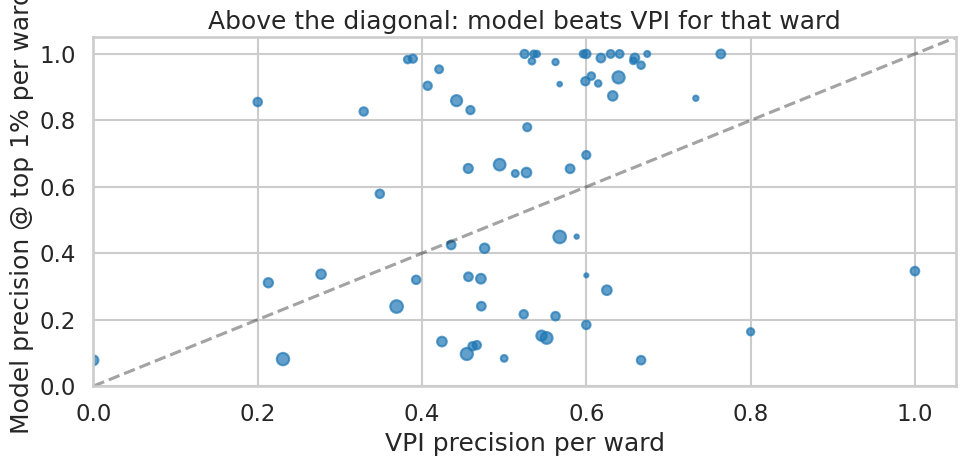

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sub = ward_compare[ward_compare['n_ovs'] >= 5].copy()
ax.scatter(sub['vpi_precision'], sub['model_precision'],
           s=sub['n_parcels'] / 200, alpha=0.7, color='#1f77b4')
lims = [0, max(sub['vpi_precision'].max(), sub['model_precision'].max(), 0.5) * 1.05]
ax.plot(lims, lims, 'k--', alpha=0.4)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('VPI precision per ward')
ax.set_ylabel(f'Model precision @ top {CAPACITY_PCT:.0%} per ward')
ax.set_title('Above the diagonal: model beats VPI for that ward')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'operational_precision_at_capacity.png',
            dpi=200, bbox_inches='tight')
plt.show()


---
**Done.** Per-ward operational flags exported. Tighten / loosen the budget by editing `CAPACITY_PCT`.

In [ ]:
!jupyter nbconvert --to html /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04e_operational_thresholds.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04e_operational_thresholds.ipynb to html
/usr/local/lib/python3.12/dist-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] Writing 316970 bytes to /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04e_operational_thresholds.html
